## Julien Kordes TP approfondi (en fin de notebook)

In [201]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import functools as ft
from sklearn.model_selection import train_test_split
from PIL import Image
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score
from torch.utils.data.sampler import WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from pylab import rcParams
import torch.optim as optim
#from google.colab import drive
import torchvision
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import torch
from torch.utils.data import random_split, Dataset, DataLoader
import os
from tqdm import tqdm

In [252]:
def plot_confusion(prediction, target):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    # init figure size
    list_labels_cat = ['ARTEFACTS',
          'BASOPHILES',
          'BLASTES',
          'EOSINOPHILES',
          'ERYTHROBLASTES',
          'LYMPHOCYTES',
          'METAMYELOCYTES',
          'MONOCYTES',
          'MYELOCYTES',
          'NEUTROPHILES',
          'PROMYELOCYTES']
    targ_valids_cat = [list_labels_cat[i] for i in target]
    preds_valids_cat = [list_labels_cat[i] for i in prediction]
    rcParams['figure.figsize'] = 7, 7
    df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize='true'), index = list_labels_cat, columns= list_labels_cat)
    # df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize = 'true'))

    fig = plt.figure()
    sns.heatmap(df, annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')



# Import features

In [253]:
#drive.mount('/content/drive')
#!ls

# Understanding an image with Python

Our images are 250x250x3 numpy matrices.

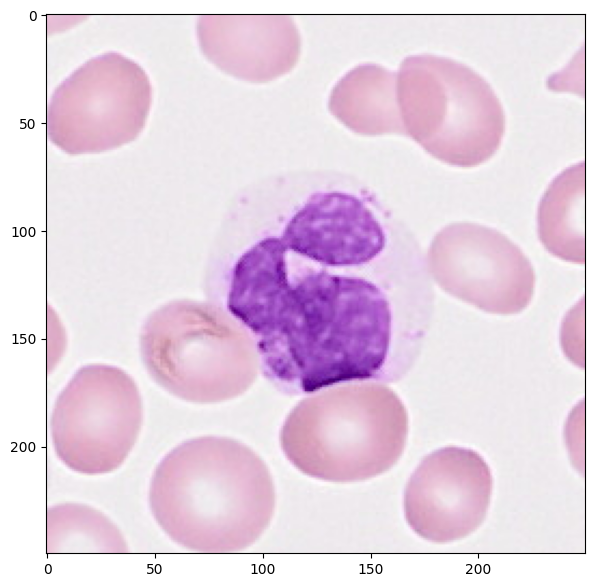

In [254]:
image = Image.open('allImages_247_282/image1.png').convert('RGB')
image = np.array(image)
plt.imshow(image)

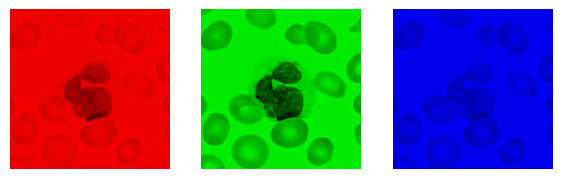

In [255]:
figure, plots = plt.subplots(ncols=3, nrows=1)
for i, subplot in zip(range(3), plots):
    temp = np.zeros(image.shape, dtype='uint8')
    temp[:,:,i] = image[:,:,i]
    subplot.imshow(temp)
    subplot.set_axis_off()
plt.show()

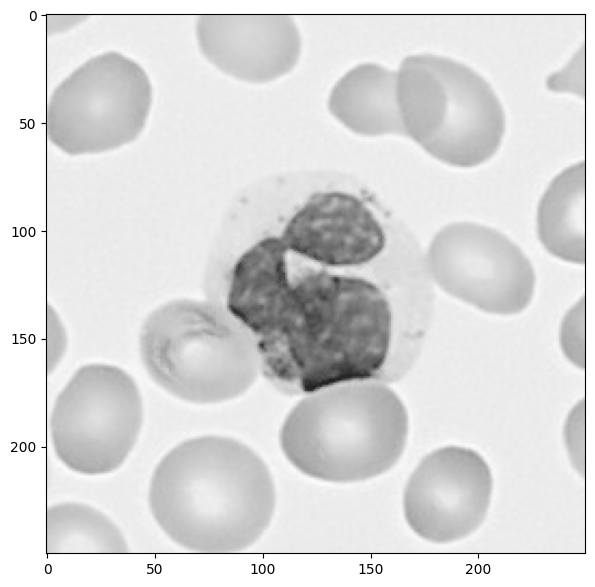

In [256]:
image_grey = Image.open('allImages_247_282/image1.png').convert('LA')
plt.imshow(image_grey)

# Image transformations

1. Using transforms package, apply the following transformations to *image*:




*   Transform from image to tensor
*   Normalize image so that all pixel values are between 0 and 1, with 0.5 mean and 0.5 standard deviation
*   Crop image
*   Put a random horizontal flip
*   Jitter the colour of the image
*   Add a gaussian blur


Remark: you can use `transforms.Compose` to use several transformations at the same time.


Examples of expected results:

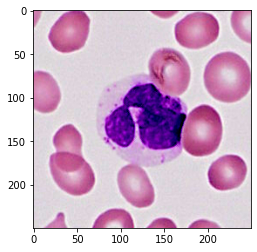


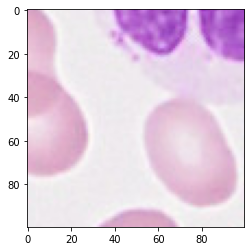

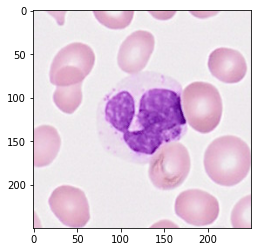

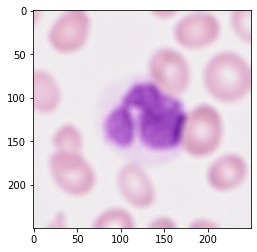



In [257]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ColorJitter(),
    transforms.GaussianBlur(5)
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9608242..0.95731455].


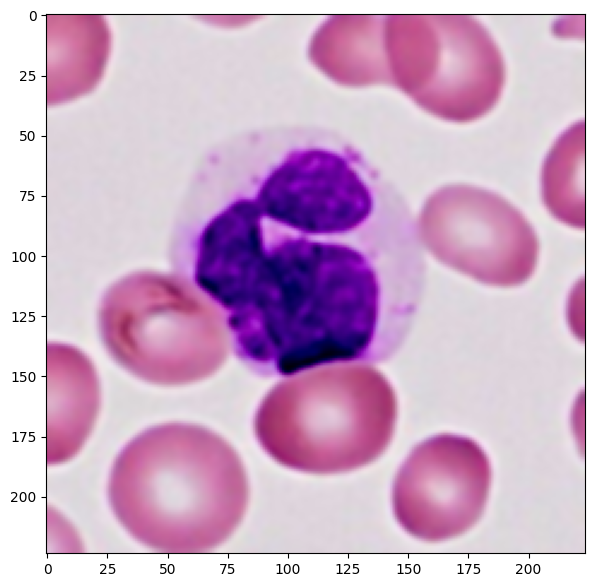

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94541335..0.95575744].


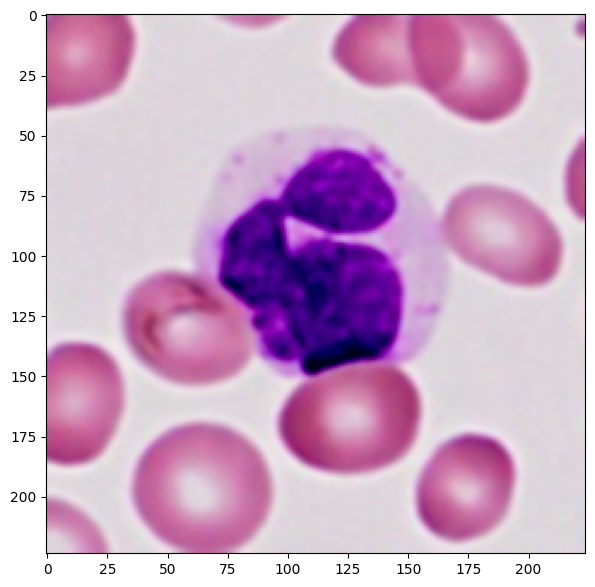

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99589133..0.9895107].


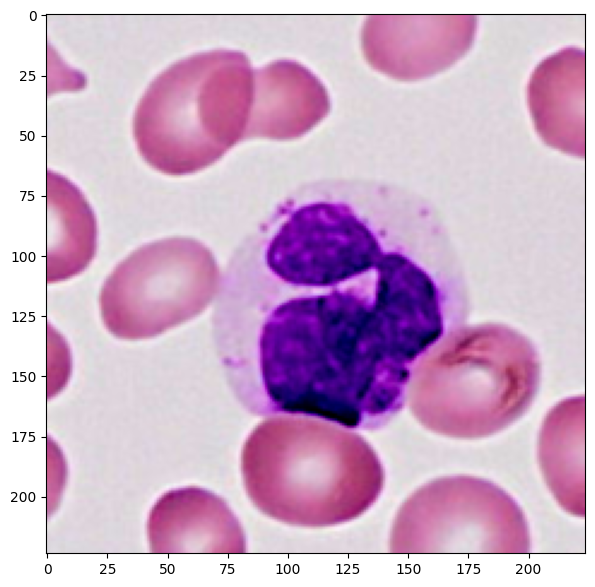

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93948233..0.95521903].


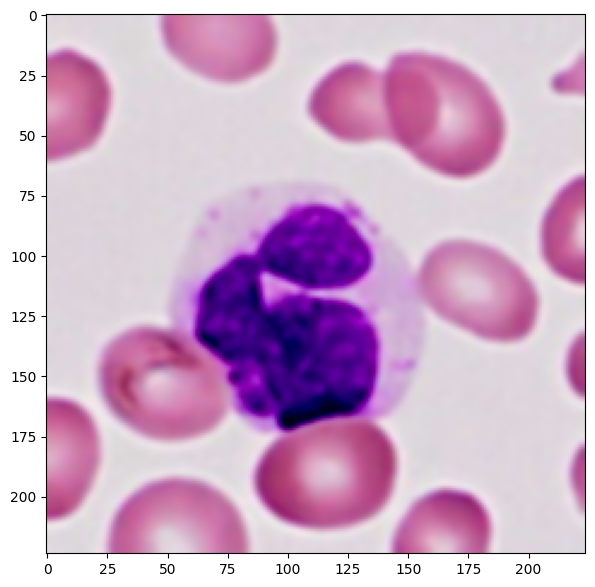

In [258]:
for _ in range(4):
    transformed_image = transform(image)
    plt.imshow(transformed_image.permute((1, 2, 0)))
    plt.show() 

# Add labels

In [259]:
labels = pd.read_csv('labels.csv')

In [260]:
labels['label'].value_counts()

label
ERYTHROBLASTES    1324
NEUTROPHILES       760
LYMPHOCYTES        357
ARTEFACTS          237
MONOCYTES          162
BLASTES             93
MYELOCYTES          78
BASOPHILES          69
METAMYELOCYTES      46
EOSINOPHILES         7
PROMYELOCYTES        7
Name: count, dtype: int64

## Labels encoding



2. a. Use the `LabelEncoder() `to convert categorical labels to numbers.

   b. Use `train_test_split` to split the dataset into 2 subdataframes `train` and `test` (test_size = 0.2, random_state = 42)


In [261]:
Encoder = LabelEncoder()
labels['label'] = Encoder.fit_transform(labels['label'])

In [262]:
train, test = train_test_split(labels, test_size=0.2, random_state=42)

# Create dataloader

3. Create 2 dataloaders, `dataloader_train` and `dataloader_test` that would form the batches from train and test subdataframes respectively. Use a `batchsize` of 8 and `shuffle=True.`


Help:
You can first create a class `MyDataset` with:

* 1 attribute: `dataframe`.
* 1 method: `__getitem__ (self, index)` that returns `X,y`, X being the tensor image, and y the associated numerical label.
* 1 method `__len__ (self)` that returns the length of the dataframe

The tutorial below can provide you some guidance if needed:

https://androidkt.com/load-pandas-dataframe-using-dataset-and-dataloader-in-pytorch/




**Bonus**: Modify `MyDataset` to add the possibility of applying a transform to the image.


In [13]:
print(labels.columns)

Index(['Unnamed: 0', 'cytoID', 'label'], dtype='object')


In [14]:
image_dir = "allImages_247_282"

df_images_to_keep_train = train
df_images_to_keep_test = test

df_images_to_keep_train["image_path"] = "image" + df_images_to_keep_train["cytoID"].astype(str) + ".png"
df_images_to_keep_test["image_path"] = "image" + df_images_to_keep_test["cytoID"].astype(str) + ".png"


all_images = set(os.listdir(image_dir))  

df_filtered_train = df_images_to_keep_train[df_images_to_keep_train["image_path"].isin(all_images)].reset_index(drop=True)
df_filtered_test = df_images_to_keep_test[df_images_to_keep_test["image_path"].isin(all_images)].reset_index(drop=True)

In [15]:
class MyDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image_path"]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")  
        label = self.df.iloc[idx]["label"]

        if self.transform:
            image = self.transform(image)

        return image, np.array([label]) 


In [16]:
Dataset_train = MyDataset(df_filtered_train, image_dir='allImages_247_282', transform=transform)
Dataset_test = MyDataset(df_filtered_test, image_dir='allImages_247_282', transform=transform)

In [17]:
Dataloader_train = DataLoader(Dataset_train, batch_size=8, shuffle=True)
Dataloader_test = DataLoader(Dataset_test, batch_size=8, shuffle=True)

## Visualization of a batch

4. Create one batch by using `next` and `iter` functions on your dataloader, and run the below cell to visualize it.

In [18]:
batch = next(iter(Dataloader_train))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9752218..0.9352302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9866805..0.9221105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99997294..0.999995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.97241545..0.97942823].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.97232014..0.9401016].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9840926..0.96530473].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0.

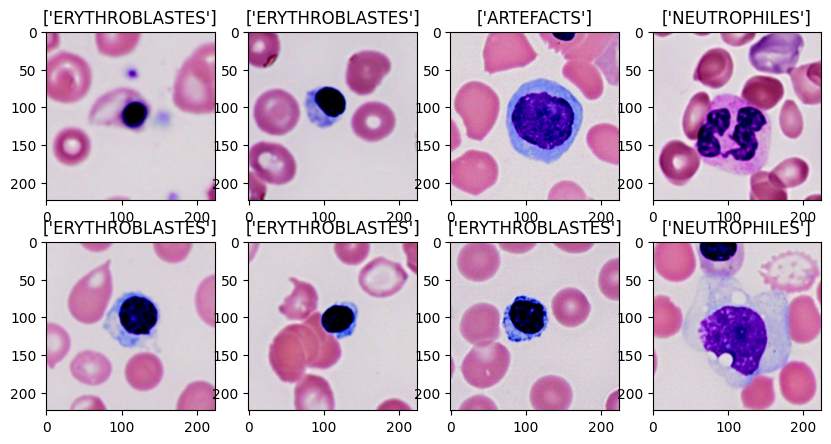

In [19]:
fig, axes = plt.subplots(2,4, figsize = ((10,5)))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[0][i].permute(2,1,0))
    ax.set_title(Encoder.inverse_transform(batch[1][i]))

# Create a model

5. Create a model from scratch, composed of
* an encoder part with convolutional layers with relu activation, and pooling layers.
* a classifier part with fully connected layers.

You are free to decide of the architecture of your model.

Warning: the last layer must be composed of as many nodes as there are classes.

Don't forget to enable the access to GPU in Edit / Notebook Settings


In [20]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.CNN = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(56*56*64, 100),
            nn.ReLU(),
            nn.Linear(100, 11)
        )

    def forward(self, x):
        x = self.CNN(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

## Define loss and optimizer

6. Create `loss` and `optimizer` variables.

`Loss` will be cross entropy loss and `optimizer` will be stochastic gradient descent.

In [21]:
model = Net()
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model

7. Create a function  `train_model(model, epochs, loss, optimizer, dataloader) ` that would train your model on a certain number of epochs `epochs`, using `loss` and `optimizer`.

Warning: you will have to put model and batches from dataloader on the gpu if you want it to run at a decent speed.


8. Use `train_model` to train the model you just created (you can run it for 3 epochs). The training will be done with `dataloader_train`.


In [22]:
def train_model(model, epochs, loss, optimizer, dataloader):
    for epoch in tqdm(range(epochs)):
        model.train()
        running_loss = 0.0
        for i, data in enumerate(dataloader):
            inputs, labels = data
            labels = labels.squeeze(1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss_ = loss(outputs, labels)
            loss_.backward()
            optimizer.step()
            running_loss += loss_.item()
        print(f"Epoch {epoch+1}, loss: {running_loss}")
    print("Finished Training")

In [23]:
train_model(model, 10, loss, optimizer, Dataloader_train)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:38<05:42, 38.06s/it]

Epoch 1, loss: 383.295239135623


 20%|██        | 2/10 [01:15<05:01, 37.67s/it]

Epoch 2, loss: 280.0048494115472


...

Epoch 8, loss: 198.31305088335648


 90%|█████████ | 9/10 [06:27<00:44, 44.85s/it]

Epoch 9, loss: 190.0016781501472


100%|██████████| 10/10 [07:11<00:00, 43.14s/it]

Epoch 10, loss: 198.27168680541217
Finished Training




# Visualise results

In [24]:
def find_accuracy(model, dataloader_test):
    correct = 0
    total = 0
    label_test = []
    predicted_test = []

    with torch.no_grad():
        for data in dataloader_test:
            images, labels = data
            label_test+= labels.squeeze().tolist()

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            predicted_test += predicted.squeeze().tolist()
            total += labels.size(0)
            correct += (predicted == labels.squeeze(1)).sum().item()

    print('Accuracy of the network on the test images: %d %%' % (
        100 * correct / total))
    return predicted_test, label_test, correct / total

9. a. Find the accuracy of the model on the testing set with the function `find_accuracy`.

  b. Plot the confusion matrix and the classification report of your model on the testing set.

  c. What do you observe ?


Example of expected result:


  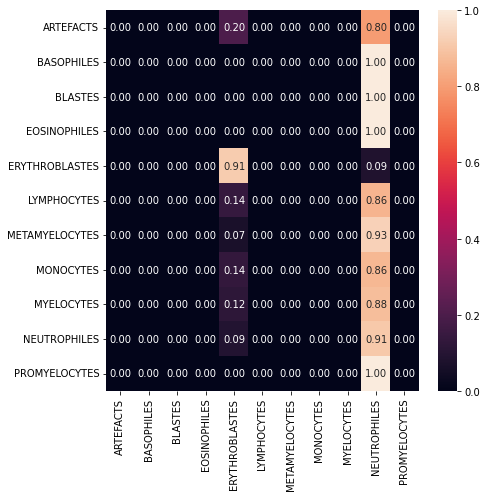

In [25]:
predicted_test, label_test, ratio = find_accuracy(model, Dataloader_test)

Accuracy of the network on the test images: 71 %


In [26]:
print(classification_report(label_test, predicted_test))

              precision    recall  f1-score   support

           0       0.78      0.33      0.46        55
           1       0.71      0.29      0.42        17
           2       0.25      0.07      0.11        15
           3       0.00      0.00      0.00         1
           4       0.90      0.94      0.92       233
           5       0.67      0.44      0.53        77
           6       0.00      0.00      0.00        15
           7       0.55      0.82      0.65        44
           8       0.12      0.06      0.08        17
           9       0.61      0.90      0.73       151
          10       0.00      0.00      0.00         3

    accuracy                           0.72       628
   macro avg       0.42      0.35      0.35       628
weighted avg       0.70      0.72      0.68       628



/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

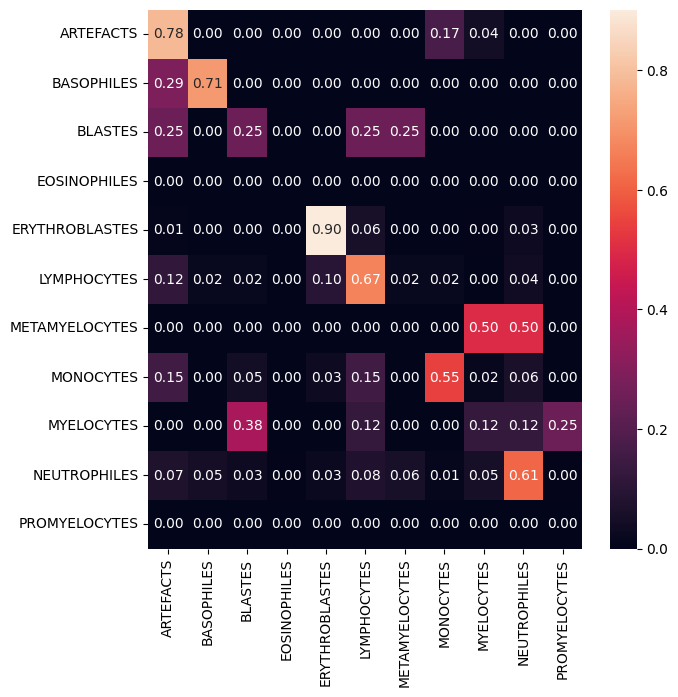

In [27]:
plot_confusion(label_test, predicted_test)

# Using a pretrained model

10. Now we will use a model that has been pretrained on ImageNet dataset. Create a new model by downloading `resnet50` from torch library, with using the option `pretrained = True`.

In [28]:
resnet = models.resnet18(pretrained=True)

/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [29]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.001)
train_model(resnet, 10, loss, optimizer, Dataloader_train)

 10%|█         | 1/10 [02:01<18:13, 121.55s/it]

Epoch 1, loss: 398.81188379228115


 20%|██        | 2/10 [04:19<17:28, 131.00s/it]

Epoch 2, loss: 314.6638616770506


 30%|███       | 3/10 [06:30<15:17, 131.12s/it]

...

Epoch 8, loss: 249.10463553667068


 90%|█████████ | 9/10 [20:56<02:26, 146.04s/it]

Epoch 9, loss: 238.62154629081488


100%|██████████| 10/10 [22:55<00:00, 137.55s/it]

Epoch 10, loss: 227.069628380239
Finished Training


11. Repeat 8 and 9 with your new model. What can you now tell about the pretrained model?





In [30]:
predicted_test_resnet, label_test_resnet, ratio_resnet = find_accuracy(resnet, Dataloader_test)

Accuracy of the network on the test images: 70 %


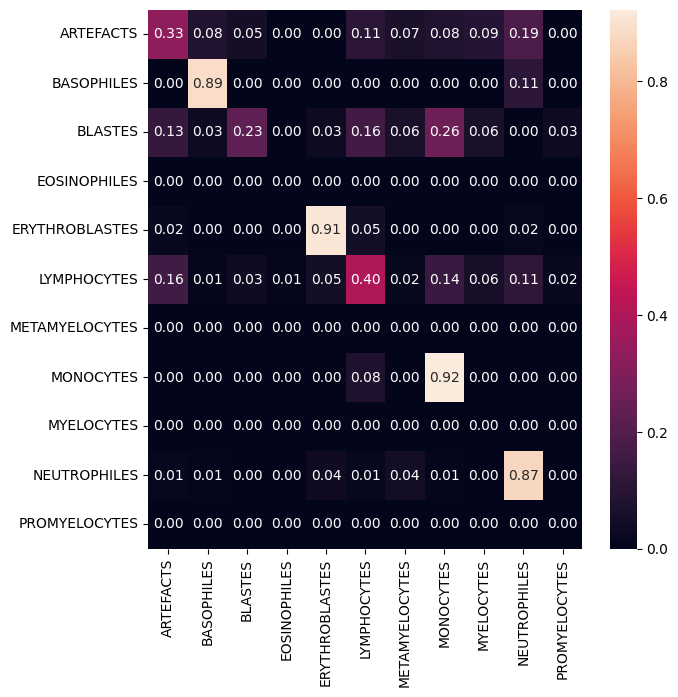

In [31]:
plot_confusion(label_test_resnet, predicted_test_resnet)

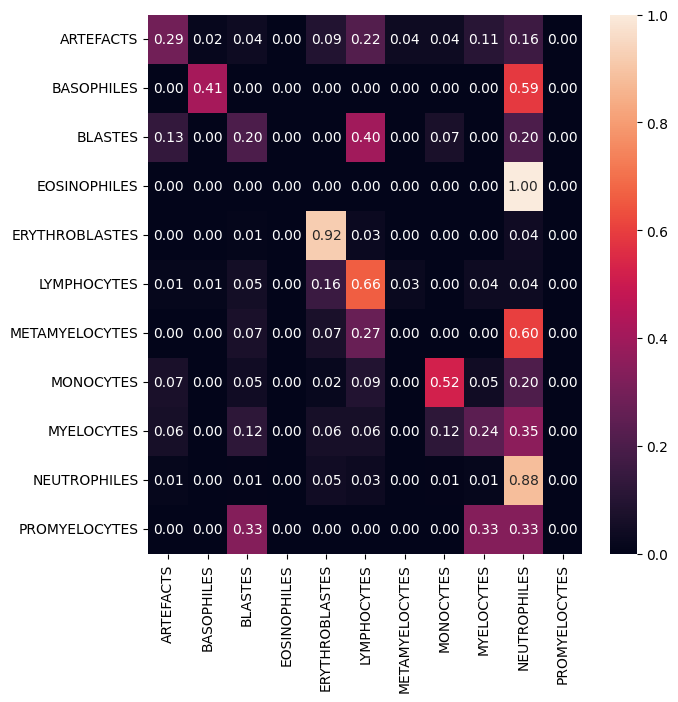

# Dealing with unbalanced classes

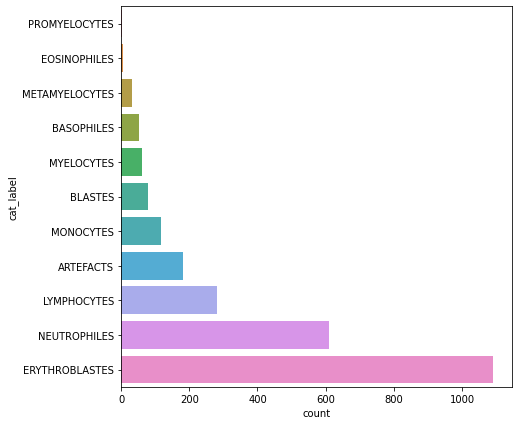

12. Even if results are getting better, underrepresented classes are still hard to classify. Create a new dataloader that would use a `WeightedRandomSampler` to make classes more balanced in every batch, and train again your model.

Remark: the training will be slower on the overrepresented classes than before, you can use a larger epochs number (such as 10 or more).

What results do you observe?

In [32]:
class_counts = np.bincount(train['label'])
class_weights = 1.0 / class_counts
sample_weights = class_weights[train['label']]  
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [33]:
dataloader = DataLoader(Dataset_train, batch_size=8, sampler=sampler)

In [34]:
model_weights = Net()
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_weights.parameters(), lr=0.001)
train_model(model_weights, 10, loss, optimizer, dataloader)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:50<07:35, 50.66s/it]

Epoch 1, loss: 602.4821605086327


 20%|██        | 2/10 [01:40<06:42, 50.33s/it]

Epoch 2, loss: 396.4827618300915


...

Epoch 8, loss: 205.19676332175732


 90%|█████████ | 9/10 [08:14<00:57, 57.97s/it]

Epoch 9, loss: 208.69879081472754


100%|██████████| 10/10 [09:18<00:00, 55.84s/it]

Epoch 10, loss: 186.18805061280727
Finished Training


In [35]:
predicted_test_model_weights, label_test_model_weights, ratio_model_weights = find_accuracy(model_weights, Dataloader_test)

Accuracy of the network on the test images: 63 %


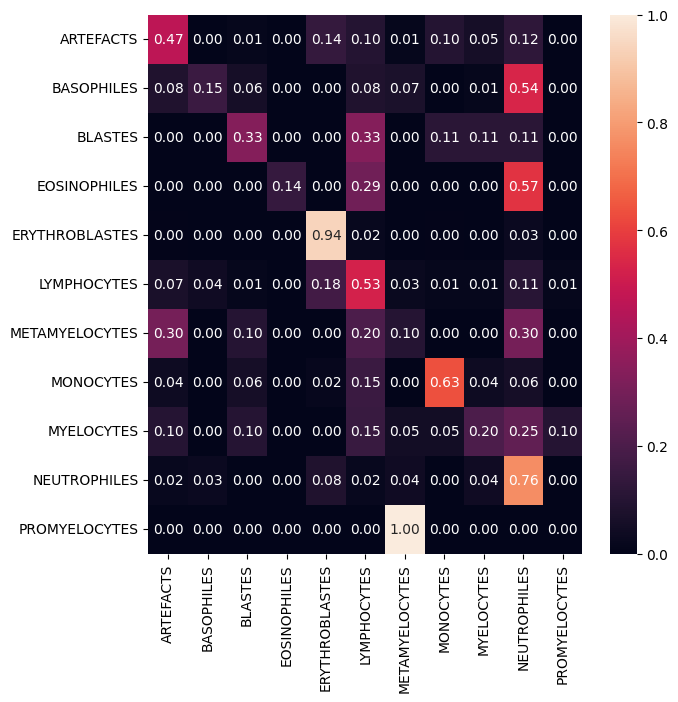

In [36]:
plot_confusion(label_test_model_weights, predicted_test_model_weights)

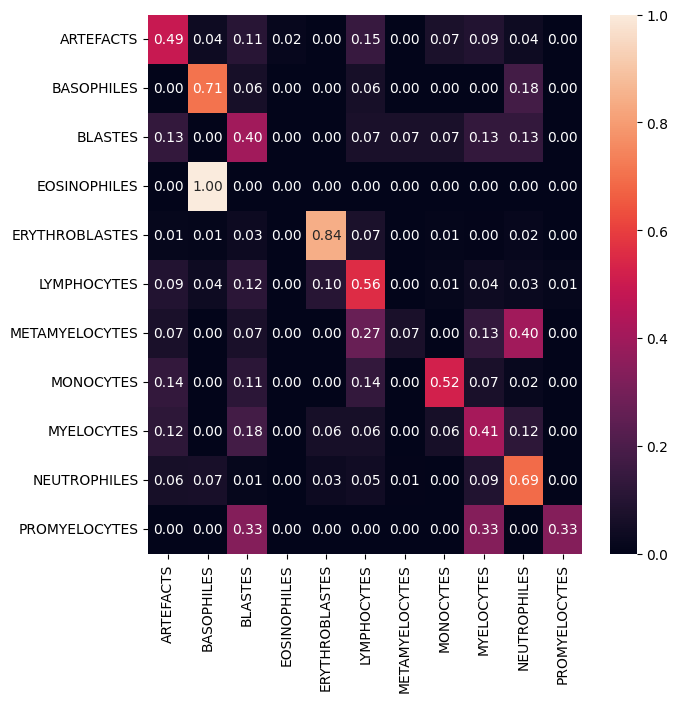

13. Discuss about the overall results, compared with Machine Learning methods
used in the first TP.

Les weights ont entraîné une perte d'accuracy globale mais permet au modèle d'être plus performant dans l'ensemble comme on peut le voir sur la matrice de confusion: il n'y a pas de classe qui est prédite complètement au hasard contrairement au premier modèle.

# Go further

If you have made it this far, you can now think about more 'exotic' models that would perform better with few data.



You can choose between these two options:

1. Try to create a siamese model. You can think of the best way to later evaluate the performance of your siamese network on this classification task.

2. Try to integrate features from the TP1 to your neural network, so that you add shape and colour information to the image. The neural network will thus have to handle in parallel table features and images.

## Approfondissement

## 1. Siamese Network

Un Siamese Network est conçu pour apprendre une mesure de similarité entre paires d’entrées. Pour l’adapter à la multiclassification, on utilise une approche où chaque entrée est comparée à des "prototypes" représentant chaque classe. On encode les entrées et les prototypes via le même réseau (poids partagés), puis on calcule une distance (ex. euclidienne) entre l’entrée et chaque prototype. On applique ensuite un softmax inversé sur les distances pour prédire la classe la plus proche.

Cela peut être particulièrement bien adapté aux cas de classes déséquilibrées, car il ne repose pas directement sur un classifieur entraîné pour chaque classe avec un nombre équilibré d'exemples. Au lieu de cela, il apprend à mesurer la similarité entre les échantillons, ce qui permet de bien généraliser même si certaines classes sont peu représentées.

In [309]:
import random

class SiameseDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

        liste_indices = []
        weights = []
        for i in range(11):
            liste_indices.append(df_filtered_train[df_filtered_train["label"] == i].index.to_list())
            weights.append((len(self.df) - len(liste_indices))**2)    #Plus il y a de représentants d'une classe moins le poids est important pour avoir moins de chance de le choisir
        self.liste_indices = liste_indices
        self.weight = weights

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Obtenez deux images et leur label
        img_name1 = self.df.iloc[idx]["image_path"]
        label_1 = self.df.iloc[idx]["label"]

        #Cela permet d'avoir plus de chance de choisir une image d'une classe minoritaire pour que le siamese network compare plus souvent aux classes minoritaires
        chosen_list = random.choices(self.liste_indices, weights=self.weight, k=1)[0]
        idx2 = random.choice(chosen_list)

        img_name2 = self.df.iloc[idx2]["image_path"]
        label_2 = self.df.iloc[idx2]["label"]    

        img_path1 = os.path.join(self.image_dir, img_name1)
        img_path2 = os.path.join(self.image_dir, img_name2)
        
        image1 = Image.open(img_path1).convert("RGB")
        image2 = Image.open(img_path2).convert("RGB")
        
        if self.transform:
            image1 = self.transform(image1)
            image2 = self.transform(image2)

        return image1, image2, np.array([label_1]), np.array([label_2])

In [310]:
class SiameseNet(nn.Module):
    def __init__(self):
        super(SiameseNet, self).__init__()
        self.CNN = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(56*56*64, 100),
            nn.ReLU(),
            nn.Linear(100, 11)
        )

    def encoder(self, x):
        x = self.CNN(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)
    
    def forward(self, input1, input2):
        output1 = self.encoder(input1)
        output2 = self.encoder(input2)
        return output1, output2

# Contrastive Loss Function
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
    
    def forward(self, output1, output2, label1, label2):
        # Euclidean distance between output1 and output2
        euclidean_distance = F.pairwise_distance(output1, output2, 2)
        label = (label1 == label2).float()
        # Contrastive loss function
        loss = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                          (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss

In [318]:
# Initialiser le dataset et le DataLoader
dataset_siamese_train = SiameseDataset(df_filtered_train, image_dir='allImages_247_282', transform=transform)
dataloader_siamese_train = DataLoader(dataset_siamese_train, batch_size = 64, shuffle=True)    

# Initialiser le modèle
model = SiameseNet()
loss_fn = ContrastiveLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [319]:
def train_siamese_network(model, num_epochs, loss, optimizer, dataloader):
    for epoch in range(num_epochs):
        running_loss = 0.0
        for img1, img2, label1, label2 in tqdm(dataloader):
            optimizer.zero_grad()
            # Passer les images dans le réseau
            output1, output2 = model(img1, img2)
            # Calculer la perte
            loss = loss_fn(output1, output2, label1, label2)
            # Rétropropagation
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch}/{num_epochs}], Loss: {running_loss}")

train_siamese_network(model, 10, loss_fn, optimizer, dataloader_siamese_train)

100%|██████████| 40/40 [01:39<00:00,  2.49s/it]


Epoch [0/10], Loss: 8.20303975045681


100%|██████████| 40/40 [01:53<00:00,  2.84s/it]


Epoch [1/10], Loss: 4.659173909574747


100%|██████████| 40/40 [01:55<00:00,  2.90s/it]


...

Epoch [7/10], Loss: 4.171794660389423


100%|██████████| 40/40 [01:54<00:00,  2.85s/it]


Epoch [8/10], Loss: 3.983517549932003


100%|██████████| 40/40 [01:54<00:00,  2.86s/it]

Epoch [9/10], Loss: 4.351895139552653


In [320]:
model.eval()

def compute_class_prototypes(dataloader, model, device='cpu'):
    model.eval()
    model.to(device)

    class_embeddings = {}  # dictionnaire {label : [liste d'embeddings]}
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            embeddings = model.encoder(images)  # [B, embedding_dim]
            
            for emb, label in zip(embeddings, labels):
                label = label.item()
                if label not in class_embeddings:
                    class_embeddings[label] = []
                class_embeddings[label].append(emb.cpu())

    # Moyenne des embeddings pour chaque classe → prototype
    prototypes = []
    class_labels = []

    for label, embs in class_embeddings.items():
        stack = torch.stack(embs, dim=0)
        prototype = stack.mean(dim=0)
        prototypes.append(prototype)
        class_labels.append(label)

    prototypes = torch.stack(prototypes, dim=0)       # [num_classes, embedding_dim]
    class_labels = torch.tensor(class_labels)         # [num_classes]

    return prototypes.to(device), class_labels.to(device)


def predict_with_prototypes(dataloader, model, prototypes, class_labels, device='cpu'):
    model.eval()
    model.to(device)

    y_preds = []
    y_trues = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            embeddings = model.encoder(images)  # [B, emb_dim]

            # distances euclidiennes [B, num_classes]
            dists = torch.cdist(embeddings, prototypes)  # [B, C]
            pred_indices = torch.argmin(dists, dim=1)    # [B]
            preds = class_labels[pred_indices]           # [B]

            y_preds.append(preds.cpu())
            y_trues.append(labels.cpu())

    y_preds = torch.cat(y_preds).numpy()
    y_trues = torch.cat(y_trues).numpy()
    return y_preds, y_trues

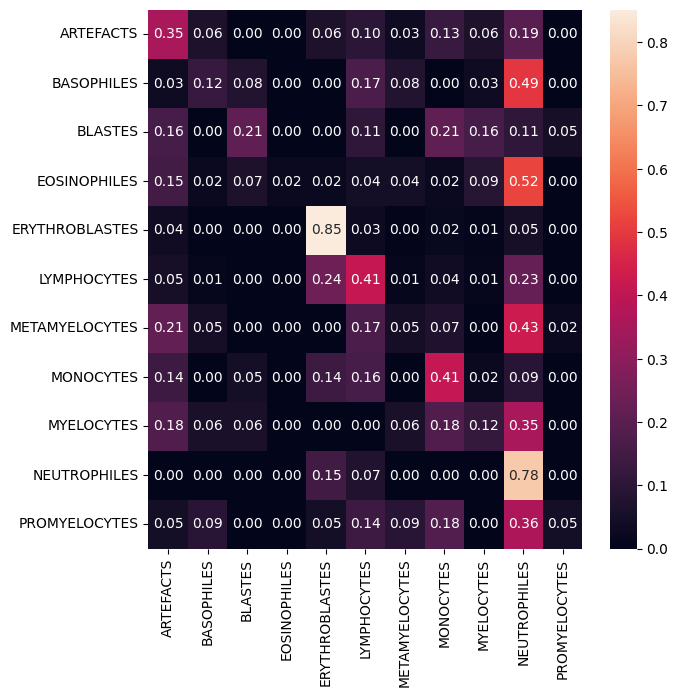

In [321]:
prototypes, class_labels = compute_class_prototypes(Dataloader_train, model)
y_pred, y_true = predict_with_prototypes(Dataloader_test, model, prototypes, class_labels)
# Évaluation
plot_confusion(np.array(y_true).astype(int).flatten(), np.array(y_pred).astype(int).flatten())

Malgré cela on remarque que les erreurs induites par le déséquilibre des classes ne sont pas corrigées par le fait que le modèle a appris dans un premier temps à mesurer la similarité entre les images

## 2. Intégration de features du TP1 

In [263]:
from sklearn.preprocessing import StandardScaler

features_table = pd.read_csv('features_table_renamed_features.csv')
dataset_tp1 = pd.merge(features_table, labels, on='cytoID')

cols_to_normalize = [col for col in dataset_tp1.columns if col not in ['cytoID', 'label']]
scaler = StandardScaler()
dataset_tp1[cols_to_normalize] = scaler.fit_transform(dataset_tp1[cols_to_normalize])

In [264]:
# Dataset hybride pour fusionner les images et les donnéees tabulaires
class HybridDataset(Dataset):
    def __init__(self, merged_df, image_dir, transform=None):
        self.df = merged_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

        # On garde la liste des colonnes de features (tout sauf image_path, label, cytoID)
        self.feature_columns = [col for col in self.df.columns if col not in ["image_path", "label", "cytoID"]]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Image
        img_name = self.df.iloc[idx]["image_path"]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # 2. Features
        features = np.array(self.df.loc[idx, self.feature_columns].values, dtype=np.float32)
        features = torch.tensor(features)

        # 3. Label
        label = torch.tensor(self.df.iloc[idx]["label_y"], dtype=torch.long)

        return image, features, label


In [265]:
# Modèle hybride pour traiter des images et des données tabulaires
class MultimodalNet(nn.Module):
    def __init__(self, num_classes=11, num_features=42):
        super().__init__()

        self.CNN = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.tabular_net = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
        )

        self.classifier = nn.Sequential(
            nn.Linear(56*56*64 + 32, 100),
            nn.ReLU(),
            nn.Linear(100, num_classes)
        )

    def forward(self, img, tabular):
        img_feat = self.CNN(img)
        img_feat = img_feat.view(img_feat.size(0), -1)

        tab_feat = self.tabular_net(tabular)

        x = torch.cat([img_feat, tab_feat], dim=1)
        out = self.classifier(x)
        return out

In [266]:
image_dir = "allImages_247_282"
df_all_images = labels
df_all_images["image_path"] = "image" + df_all_images["cytoID"].astype(str) + ".png"
all_images = set(os.listdir(image_dir))  
df_filtered = df_all_images[df_all_images["image_path"].isin(all_images)].reset_index(drop=True)

In [267]:
merged_df = pd.merge(df_filtered, dataset_tp1, on="cytoID", how="inner")
merged_df = merged_df.dropna()
merged_df = merged_df.drop(columns=["Unnamed: 0_x", "label_x", "Unnamed: 0_y"])
merged_df_train ,merged_df_test = train_test_split(merged_df, test_size = 0.2, random_state=42)

In [268]:
# Création du dataset
hybrid_dataset_train = HybridDataset(merged_df_train, image_dir="allImages_247_282", transform=transform)
hybrid_dataset_test = HybridDataset(merged_df_test, image_dir="allImages_247_282", transform=transform)
hybrid_dataloader_train = DataLoader(hybrid_dataset_train, batch_size = 64, shuffle = True)
hybrid_dataloader_test = DataLoader(hybrid_dataset_test, batch_size = 64, shuffle = True)

In [273]:
model = MultimodalNet()
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
nb_epochs = 15

In [274]:
#Boucle d'entraînement
for epoch in tqdm(range(nb_epochs)):
    model.train()
    running_loss = 0.0
    for images, features, labels in hybrid_dataloader_train:
        optimizer.zero_grad()
        logits = model(images, features)
        loss_ = loss(logits, labels)
        loss_.backward()
        optimizer.step()
        running_loss += loss_.item()
    print(f"Epoch {epoch + 1}, loss: {running_loss}")

  7%|▋         | 1/15 [00:47<10:58, 47.01s/it]

Epoch 1, loss: 77.23572587966919


 13%|█▎        | 2/15 [01:55<12:55, 59.62s/it]

Epoch 2, loss: 41.86514472961426


 20%|██        | 3/15 [03:00<12:27, 62.32s/it]

...

Epoch 13, loss: 13.78799793124199


 93%|█████████▎| 14/15 [14:37<01:04, 64.72s/it]

Epoch 14, loss: 10.311070278286934


100%|██████████| 15/15 [15:41<00:00, 62.75s/it]

Epoch 15, loss: 9.4690977409482


In [275]:
def find_accuracy_model_hybrid(model, dataloader_test):
    correct = 0
    total = 0
    label_test = []
    predicted_test = []

    with torch.no_grad():
        for data in dataloader_test:
            images, features, labels = data
            label_test+= labels.squeeze().tolist()

            outputs = model(images, features)
            _, predicted = torch.max(outputs.data, 1)
            predicted_test += predicted.squeeze().tolist()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: %d %%' % (
        100 * correct / total))
    return predicted_test, label_test, correct / total

Accuracy of the network on the test images: 88 %


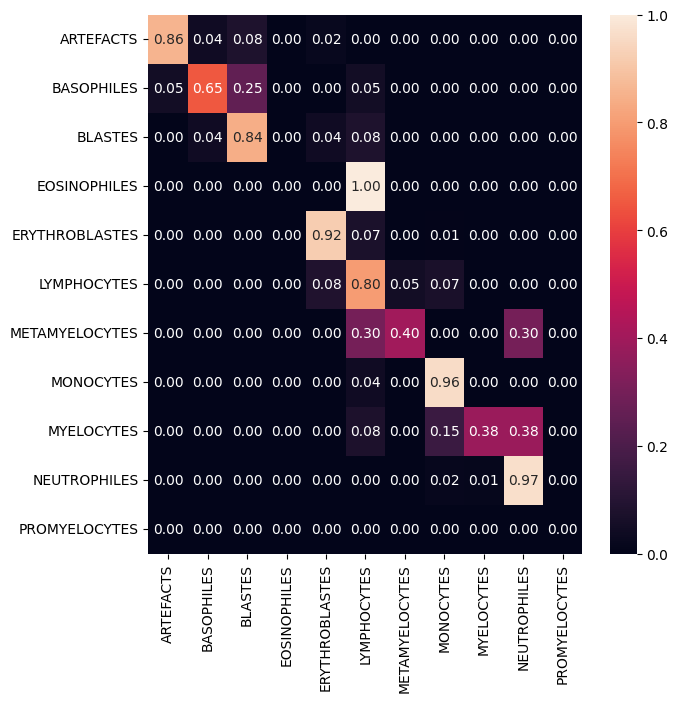

In [276]:
pred, lab, ratio = find_accuracy_model_hybrid(model, hybrid_dataloader_test)
plot_confusion(pred, lab)

L'accuracy du réseau passe de 63% (en utilisant que les images) à 88% lorsqu'on rajoute les données tabulaires du TP1